In [ ]:
from pst.utils import *
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


rng = np.random.default_rng(42)

# ------------- synthetic truth + sampling -----------------

def gauss(x, mu, sig, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sig) ** 2)

def add_features(lam_truth, truth, add_lines=True, n_lines=5,
                 add_outliers=True, n_outliers=5,
                 add_gap=True, gap_range=[5400, 5600]):
    
    f_mean = truth.mean()
    noise = rng.normal(0, f_mean.value / 30, size=truth.size)
    f = truth + noise * truth.unit
    
    if add_lines:
        wl_c = np.random.choice(lam_truth, size=n_lines,
                                replace=False) * lam_truth.unit
        line_sigma = np.random.uniform(0.5, 5, size=n_lines) * lam_truth.unit
        line_amplitude = np.random.uniform(
             f_mean.value * 1.1, f_mean.value * 10, size=n_lines)

        for c, s, a in zip(wl_c, line_sigma, line_amplitude):
            f += gauss(lam_truth, c, s, a) * f_mean.unit
    
    mask = np.ones_like(f.value, dtype=bool)

    if add_outliers:
        outliers = np.random.randint(0, lam_truth.size, size=n_outliers)
        f[outliers] += 5.0 << f_mean.unit
        mask[outliers] = False
    
    if add_gap:
        gap_s, gap_e = np.searchsorted(lam_truth, gap_range)
        mask[gap_s : gap_e] = False

    return lam_truth, f, mask


In [14]:
from pst.SSP import PopStar

ssp = PopStar(IMF="CHA")
ssp.cut_wavelength(3000, 10000)

lam_truth, truth = ssp.wavelength, ssp.L_lambda[2, 10]

w_out = np.linspace(lam_truth[0], lam_truth[-1], 400)

> Initialising Popstar models (IMF='CHA')
--> Only stellar continuum
[SSP] Models cut between 3000.0 Angstrom 10000.0 Angstrom


In [15]:
w_in, f_in_noisy, mask_valid = add_features(
        lam_truth, truth,
        add_outliers=False,
        add_gap=False)

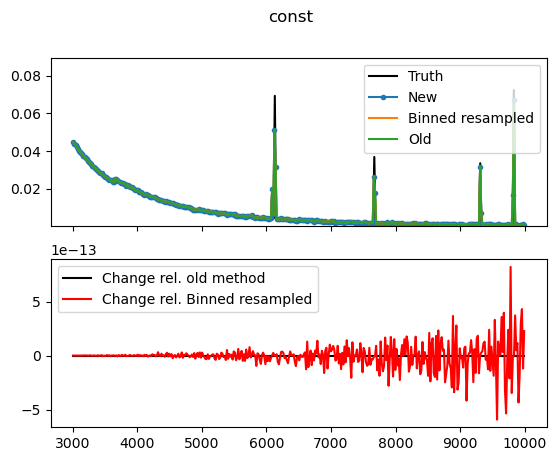

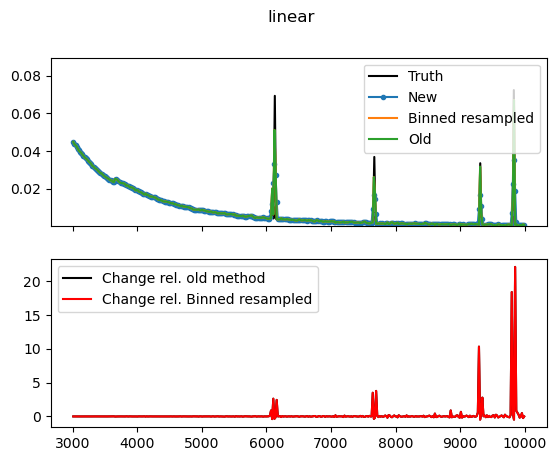

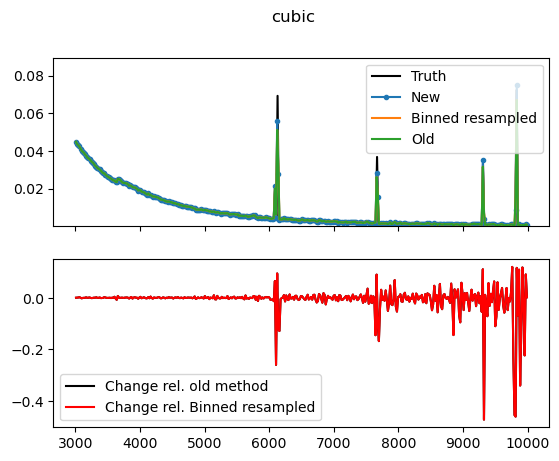

In [16]:
f_out_old = flux_conserving_interpolation(w_out, w_in, f_in_noisy)

f_out_res = spectra_flux_conserving_interpolation(w_out, w_in, f_in_noisy, method="binfrac")

methods = ["const", "linear", "cubic"]
f_out_dict = {}
for m in methods:
    f_out_dict[m] = spectra_flux_conserving_interpolation(
        w_out, w_in, f_in_noisy, mask_valid=mask_valid, method="cumulative", kind=m,
        fill_value=np.nan
    )

    fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
    fig.suptitle(m)
    ax = axs[0]
    ax.plot(w_in, f_in_noisy, label="Truth", c="k")
    ax.plot(w_out, f_out_dict[m], ".-", label="New")
    ax.plot(w_out, f_out_res, label="Binned resampled")
    ax.plot(w_out, f_out_old, label="Old")
    ax.set_ylim(truth.value.min() / 2, truth.value.max() * 2)
    ax.legend()
    ax = axs[1]
    ax.plot(w_out, (f_out_dict[m] - f_out_old) / f_out_old,
            c="k", label="Change rel. old method")
    ax.plot(w_out, (f_out_dict[m] - f_out_res) / f_out_res,
            c="r", label="Change rel. Binned resampled")
    ax.legend()
    # ax.set_yscale("symlog", linthresh=0.5)


In [17]:
import time

In [19]:
n_iter = 300
mean_time = np.zeros(len(methods)
                     )
for ith, m in enumerate(methods):
    t0 = time.time()
    for i in range(n_iter):
        f_out_dict[m] = spectra_flux_conserving_interpolation(
            w_out, w_in, f_in_noisy, mask_valid=mask_valid, kind=m,
            fill_value=np.nan
        )
    te = time.time() - t0
    mean_time[ith] = te / n_iter
    print(f"[{m}] Mean time per call", mean_time[ith])

t0 = time.time()
for i in range(n_iter):
    f_out_old = flux_conserving_interpolation(w_out, w_in, f_in_noisy)
te = time.time() - t0
old_mean = te / n_iter
print(f"[Old] Mean time per call", old_mean)
print("Relative difference", mean_time / old_mean)

t0 = time.time()
for i in range(n_iter):
    f_out_res = spectra_flux_conserving_interpolation(w_out, w_in, f_in_noisy, method="binfrac")
te = time.time() - t0
bin_mean = te / n_iter
print(f"[Binned] Mean time per call", bin_mean)
print("Relative difference", bin_mean / old_mean)


[const] Mean time per call 8.615016937255859e-05
[linear] Mean time per call 8.292277654012044e-05
[cubic] Mean time per call 0.000195770263671875
[Old] Mean time per call 0.00021705389022827148
Relative difference [0.39690682 0.38203773 0.90194312]
[Binned] Mean time per call 0.00015803734461466472
Relative difference 0.7281018757528825
